# Per-Series Feature Importance with xeries

This notebook demonstrates how to compute and visualize feature importance **separately for each time series** using the `explain_per_series()` method. This allows you to inspect how feature importance varies across different series in your multi-series forecasting data.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from xeries import (
    ConditionalPermutationImportance,
    ManualPartitioner,
    plot_importance_bar,
    plot_importance_heatmap,
    plot_importance_per_series,
)

## 1. Create Sample Multi-Series Data

We'll create synthetic time series data for 6 stores across 2 regions (urban and rural) with hourly observations.

Data shape: (1200, 4)
Series: ['store_001', 'store_002', 'store_003', 'store_004', 'store_005', 'store_006']
Regions: {'store_001': 'urban', 'store_002': 'urban', 'store_003': 'urban', 'store_004': 'rural', 'store_005': 'rural', 'store_006': 'rural'}
                 date  series_id region       value
0 2023-01-01 00:00:00  store_001  urban  102.483571
1 2023-01-01 01:00:00  store_001  urban  104.535311
2 2023-01-01 02:00:00  store_001  urban  113.338945
3 2023-01-01 03:00:00  store_001  urban  121.908039
4 2023-01-01 04:00:00  store_001  urban  116.350746
5 2023-01-01 05:00:00  store_001  urban  118.399088
6 2023-01-01 06:00:00  store_001  urban  128.197572
7 2023-01-01 07:00:00  store_001  urban  123.507449
8 2023-01-01 08:00:00  store_001  urban  115.375146
9 2023-01-01 09:00:00  store_001  urban  117.307197


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_8932\1904139506.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2023-01-01', periods=n_points, freq='H')


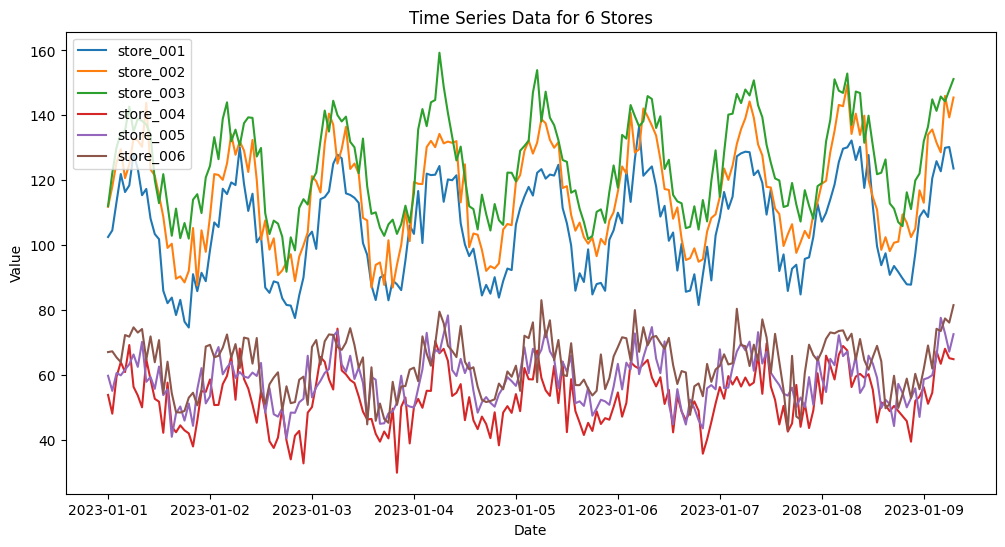

In [21]:
np.random.seed(42)

# Create 6 series with different characteristics
series_ids = ['store_001', 'store_002', 'store_003', 'store_004', 'store_005', 'store_006']
regions = ['urban', 'urban', 'urban', 'rural', 'rural', 'rural']
n_points = 200  # Points per series

all_data = []

for i, (series_id, region) in enumerate(zip(series_ids, regions)):
    dates = pd.date_range(start='2023-01-01', periods=n_points, freq='H')
    
    # Different patterns for different regions
    if region == 'urban':
        # Urban stores: strong daily pattern, higher baseline
        base = 100 + i * 10
        hourly_pattern = 20 * np.sin(2 * np.pi * np.arange(n_points) / 24)
        trend = np.linspace(0, 10, n_points)
    else:
        # Rural stores: weaker daily pattern, more noise
        base = 50 + (i - 3) * 5
        hourly_pattern = 10 * np.sin(2 * np.pi * np.arange(n_points) / 24)
        trend = np.linspace(0, 5, n_points)
    
    values = base + hourly_pattern + trend + np.random.normal(0, 5, n_points)
    
    df = pd.DataFrame({
        'date': dates,
        'series_id': series_id,
        'region': region,
        'value': values
    })
    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f"Data shape: {data.shape}")
print(f"Series: {data['series_id'].unique().tolist()}")
print(f"Regions: {dict(zip(series_ids, regions))}")
print(data.head(10))

# Plot the time series
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id]
    plt.plot(subset['date'], subset['value'], label=series_id)
plt.title('Time Series Data for 6 Stores')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## 2. Create Lag Features

Create lag features for each series, which will be used by our model.

In [3]:
# Create lag features for each series
n_lags = 5

def create_lag_features(group):
    group = group.copy()
    for lag in range(1, n_lags + 1):
        group[f'lag_{lag}'] = group['value'].shift(lag)
    return group

data = data.groupby('series_id', group_keys=False).apply(create_lag_features)
data = data.dropna().reset_index(drop=True)

# Prepare features and target
feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)]
X = data[feature_cols + ['series_id']].copy()
y = data['value'].values

# Map series_id to integer codes for the model
series_mapping = {s: i for i, s in enumerate(series_ids)}
X['series_code'] = X['series_id'].map(series_mapping)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (1170, 7)
y shape: (1170,)


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_8932\4189102192.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('series_id', group_keys=False).apply(create_lag_features)


,lag_1,lag_2,lag_3,lag_4,lag_5,series_id,series_code
0,116.350746,121.908039,113.338945,104.535311,102.483571,store_001,0
1,118.399088,116.350746,121.908039,113.338945,104.535311,store_001,0
2,128.197572,118.399088,116.350746,121.908039,113.338945,store_001,0
3,123.507449,128.197572,118.399088,116.350746,121.908039,store_001,0
4,115.375146,123.507449,128.197572,118.399088,116.350746,store_001,0


## 3. Train a Global Model

Train a single Random Forest model on all series combined.

In [4]:
# Train model on numeric features (lags + series code)
model_features = feature_cols + ['series_code']
X_train = X[model_features]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y)

print(f"Model R² score: {model.score(X_train, y):.4f}")

Model R² score: 0.9937


## 4. Compute Per-Series Feature Importance

Use `explain_per_series()` to compute feature importance separately for each store. This shows how the importance of each lag feature varies across different series.

In [14]:
# Create explainer
explainer = ConditionalPermutationImportance(
    model=model,
    metric='mse',
    n_repeats=5,
    random_state=42
)

# Compute per-series importance
per_series_results = explainer.explain_per_series(
    X=X_train,
    y=y,
    series_col='series_code',  # Use the series identifier column
    features=feature_cols  # Only compute for lag features
)

# Map numeric codes back to series names for better display
reverse_mapping = {v: k for k, v in series_mapping.items()}
per_series_results = {reverse_mapping[k]: v for k, v in per_series_results.items()}

print(f"Computed importance for {len(per_series_results)} series")
print(f"Series: {list(per_series_results.keys())}")

Computed importance for 6 series
Series: ['store_001', 'store_002', 'store_003', 'store_004', 'store_005', 'store_006']


## 5. View Individual Series Results

Examine the importance scores for each series individually.

In [15]:
for series_id, result in per_series_results.items():
    print(f"\n=== {series_id} ===")
    print(result.to_dataframe().to_string(index=False))


=== store_001 ===
feature  importance       std
  lag_1  288.821188 28.330049
  lag_5   37.271827  3.103263
  lag_2   31.946078  4.411007
  lag_3   11.462045  0.534092
  lag_4   10.425271  0.540271

=== store_002 ===
feature  importance       std
  lag_1  329.109858 39.357354
  lag_5   42.682343  6.451944
  lag_2   31.242750  3.039305
  lag_3   15.911705  2.592406
  lag_4    7.831240  0.460695

=== store_003 ===
feature  importance       std
  lag_1  343.606514 37.343716
  lag_5   34.062957  2.486088
  lag_2   23.814724  2.104357
  lag_3   13.105012  0.818833
  lag_4    9.924610  0.285268

=== store_004 ===
feature  importance      std
  lag_1   50.625604 4.544808
  lag_2   27.827824 1.163654
  lag_3   15.826457 1.283670
  lag_5   11.164956 1.454931
  lag_4   10.649410 0.118020

=== store_005 ===
feature  importance      std
  lag_1   48.911341 5.273123
  lag_2   25.842398 1.603195
  lag_5   13.879983 1.677889
  lag_3    9.840769 0.908712
  lag_4    8.766553 0.802202

=== store_006 ==

## 6. Visualize Per-Series Importance (Grid Layout)

Use `plot_importance_per_series()` to create a grid of bar charts showing importance for each series.

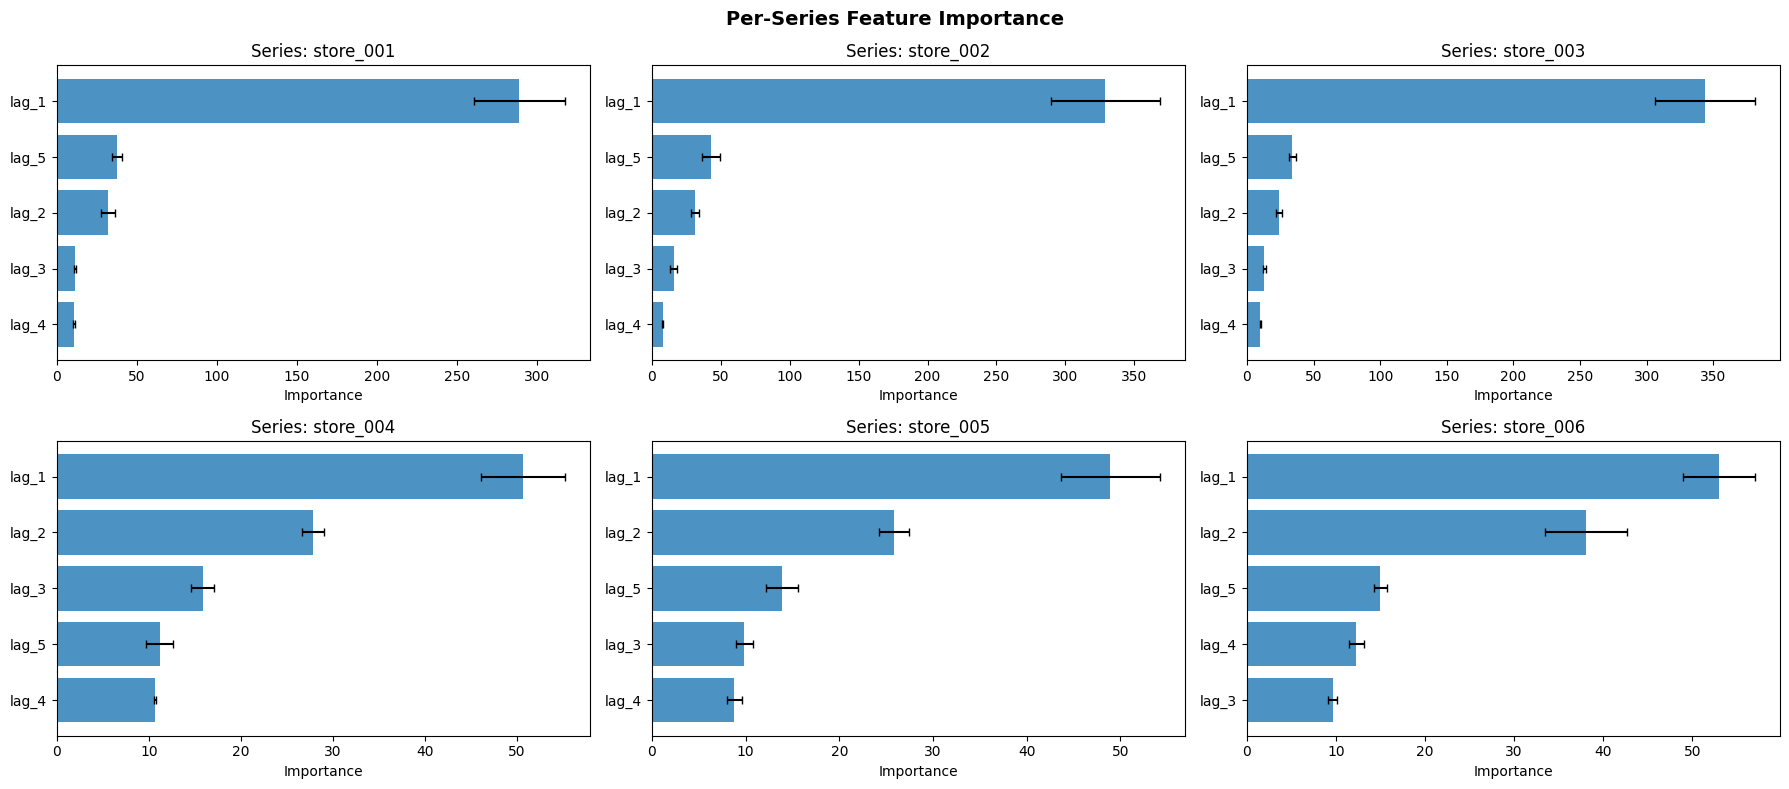

In [7]:
fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=5,
    ncols=3,
    title="Per-Series Feature Importance"
)

## 7. Compare Series with Heatmap

Use the existing `plot_importance_heatmap()` to compare feature importance across all series in a single view.

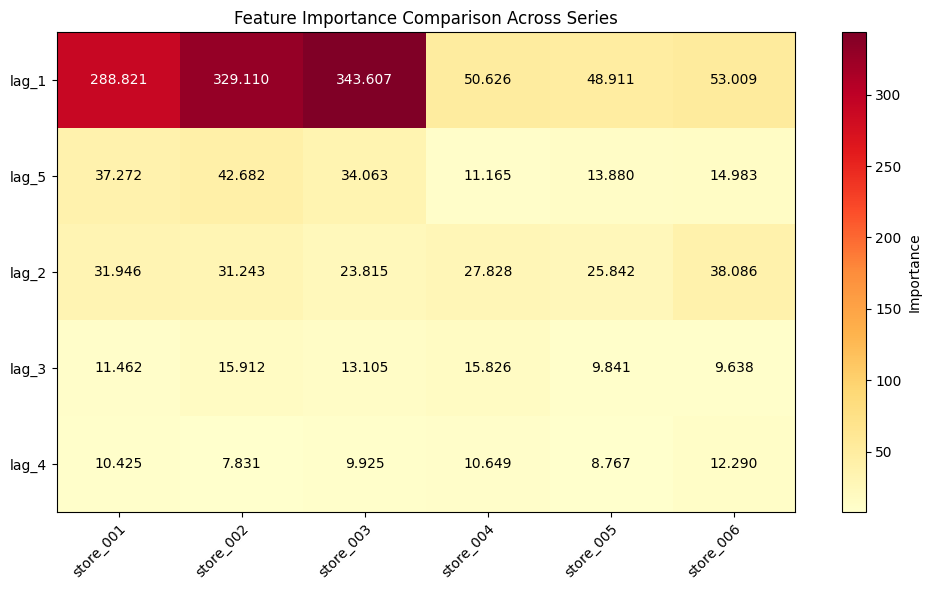

In [8]:
fig, ax = plot_importance_heatmap(
    per_series_results,
    features=feature_cols,
    figsize=(10, 6),
    title="Feature Importance Comparison Across Series"
)

## 8. Group Series by Region

Aggregate results by region to see if urban and rural stores have different feature importance patterns.

In [16]:
# Group series by region
region_mapping = dict(zip(series_ids, regions))

urban_series = [s for s in series_ids if region_mapping[s] == 'urban']
rural_series = [s for s in series_ids if region_mapping[s] == 'rural']

print(f"Urban stores: {urban_series}")
print(f"Rural stores: {rural_series}")

Urban stores: ['store_001', 'store_002', 'store_003']
Rural stores: ['store_004', 'store_005', 'store_006']


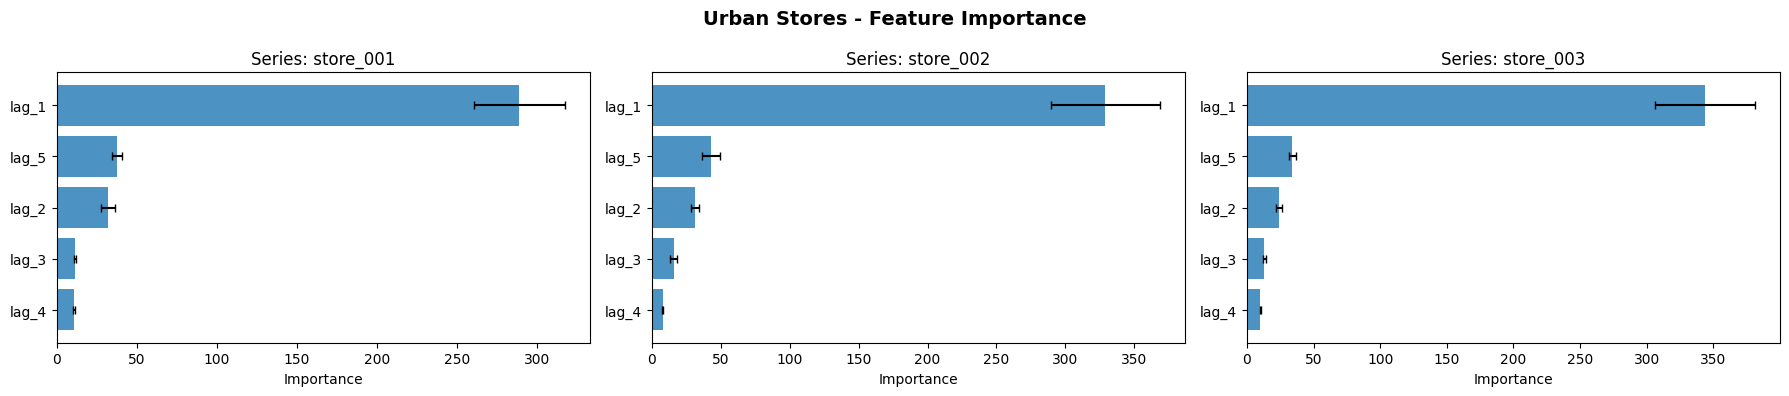

In [17]:
# Plot urban stores
urban_results = {k: v for k, v in per_series_results.items() if k in urban_series}
fig, axes = plot_importance_per_series(
    urban_results,
    max_features=5,
    ncols=3,
    title="Urban Stores - Feature Importance"
)

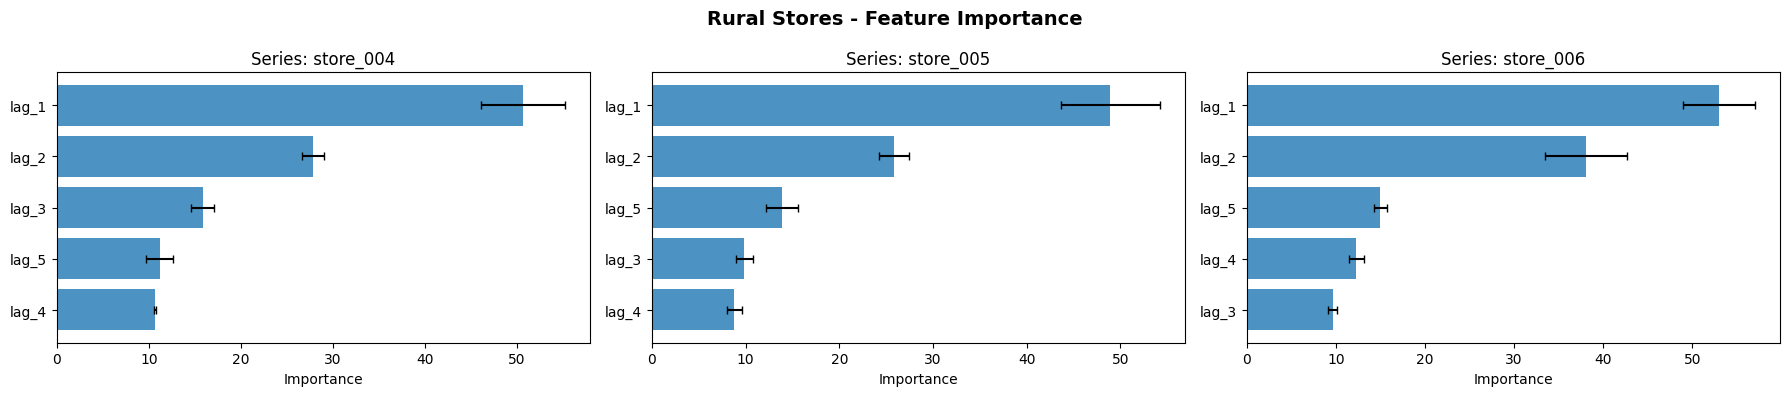

In [18]:
# Plot rural stores
rural_results = {k: v for k, v in per_series_results.items() if k in rural_series}
fig, axes = plot_importance_per_series(
    rural_results,
    max_features=5,
    ncols=3,
    title="Rural Stores - Feature Importance"
)

## 9. Compare Urban vs Rural with Aggregated Importance

Compute the average importance for each region to see high-level differences.

In [19]:
# Aggregate importance by region
def aggregate_importance(results_dict):
    """Average importance across multiple series."""
    all_importances = {}
    for series_id, result in results_dict.items():
        for feat, imp in zip(result.feature_names, result.importances):
            if feat not in all_importances:
                all_importances[feat] = []
            all_importances[feat].append(imp)
    
    return {feat: np.mean(vals) for feat, vals in all_importances.items()}

urban_avg = aggregate_importance(urban_results)
rural_avg = aggregate_importance(rural_results)

comparison_df = pd.DataFrame({
    'Urban (avg)': urban_avg,
    'Rural (avg)': rural_avg
}).sort_values('Urban (avg)', ascending=False)

print("Average Feature Importance by Region:")
comparison_df

Average Feature Importance by Region:


,Urban (avg),Rural (avg)
lag_1,320.512520,50.848753
lag_5,38.005709,13.342585
lag_2,29.001184,30.585297
lag_3,13.492921,11.768258
lag_4,9.393707,10.568553


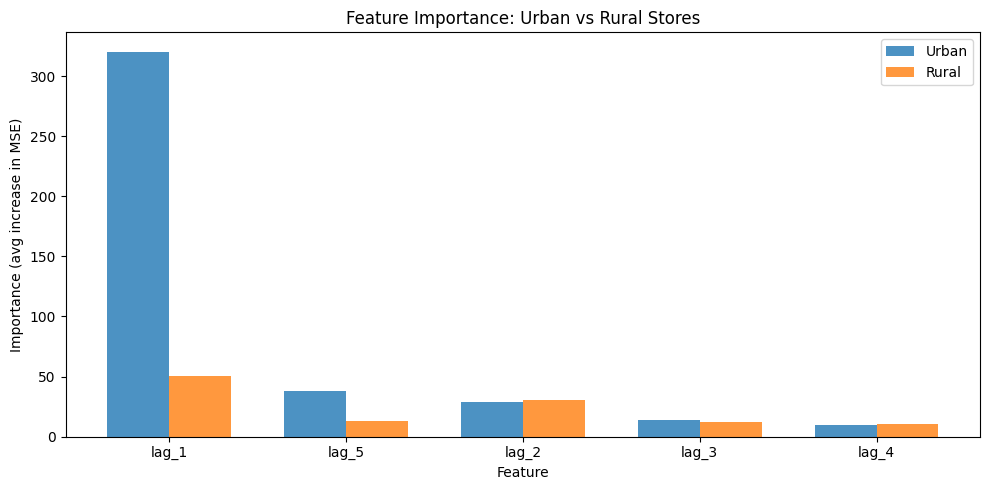

In [13]:
# Visualize the comparison
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Urban (avg)'], width, label='Urban', alpha=0.8)
ax.bar(x + width/2, comparison_df['Rural (avg)'], width, label='Rural', alpha=0.8)

ax.set_xlabel('Feature')
ax.set_ylabel('Importance (avg increase in MSE)')
ax.set_title('Feature Importance: Urban vs Rural Stores')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.legend()
plt.tight_layout()

## Summary

In this notebook, we demonstrated:

1. **Per-Series Importance**: Using `explain_per_series()` to compute feature importance separately for each time series
2. **Grid Visualization**: Using `plot_importance_per_series()` to display importance charts for multiple series in a grid layout
3. **Heatmap Comparison**: Using `plot_importance_heatmap()` to compare importance across all series
4. **Regional Grouping**: Filtering and aggregating results by domain-specific groups (urban vs rural)

This approach is valuable when:
- You suspect different series may have different feature importance patterns
- You want to identify series that behave differently from others
- You need to understand how importance varies across business segments or regions